# Feature Importance Analysis in Diabetes Prediction

## Objective
The goal of this analysis is to identify which features most influence diabetes prediction using statistical and machine learning methods.

## Why This Matters
Understanding feature importance improves model interpretability and helps build reliable healthcare systems.

## Dataset

This project uses the Pima Indians Diabetes dataset, which contains medical diagnostic measurements for predicting diabetes.

### Features:
- Pregnancies
- Glucose
- Blood Pressure
- Skin Thickness
- Insulin
- BMI
- Diabetes Pedigree Function (DPF)
- Age

Target:
- Outcome (0 = No diabetes, 1 = Diabetes)

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance

plt.rcParams['figure.dpi'] = 120
sns.set_style("whitegrid")

In [12]:
import urllib.request

url = "https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv"
urllib.request.urlretrieve(url, "diabetes.csv")

df = pd.read_csv("diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [13]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


## Data Cleaning

Certain features contained invalid zero values (e.g., Glucose, BMI), which are not physiologically possible. These were treated as missing values.

We replaced them with median values to maintain robustness and avoid skewing the data.

In [14]:
zero_cols = ["Glucose","BloodPressure","SkinThickness","Insulin","BMI"]

df_clean = df.copy()
df_clean[zero_cols] = df_clean[zero_cols].replace(0, np.nan)
df_clean.fillna(df_clean.median(), inplace=True)

## Methods Used

We used three approaches to evaluate feature importance:

1. Correlation Analysis  
2. Random Forest Feature Importance  
3. Permutation Importance  

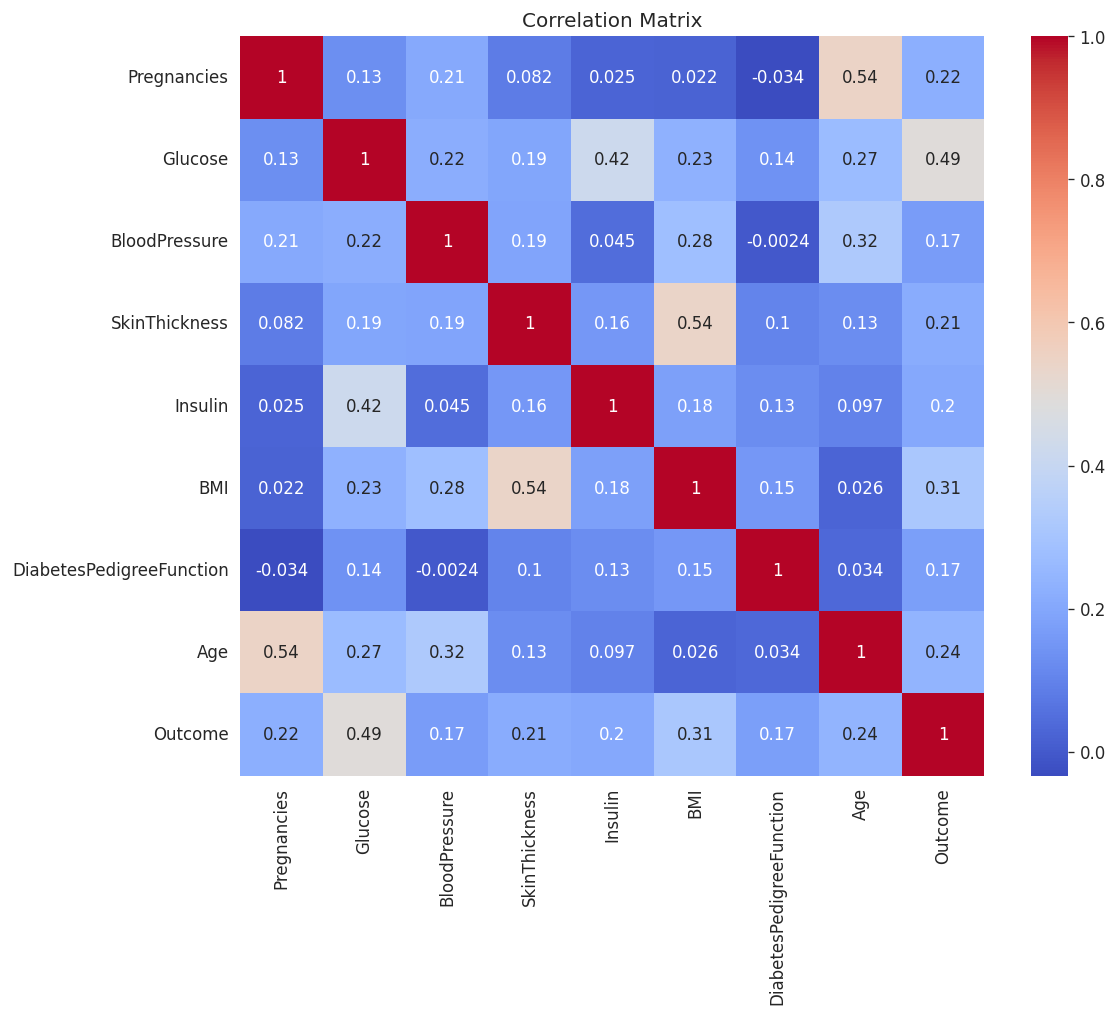

In [15]:
plt.figure(figsize=(10,8))
sns.heatmap(df_clean.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

## Results

The following visualizations show feature importance using different methods.

In [16]:
X = df_clean.drop("Outcome", axis=1)
y = df_clean["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier(n_estimators=200, max_depth=5, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(max_depth=5, n_estimators=200, random_state=42)

### Random Forest Feature Importance

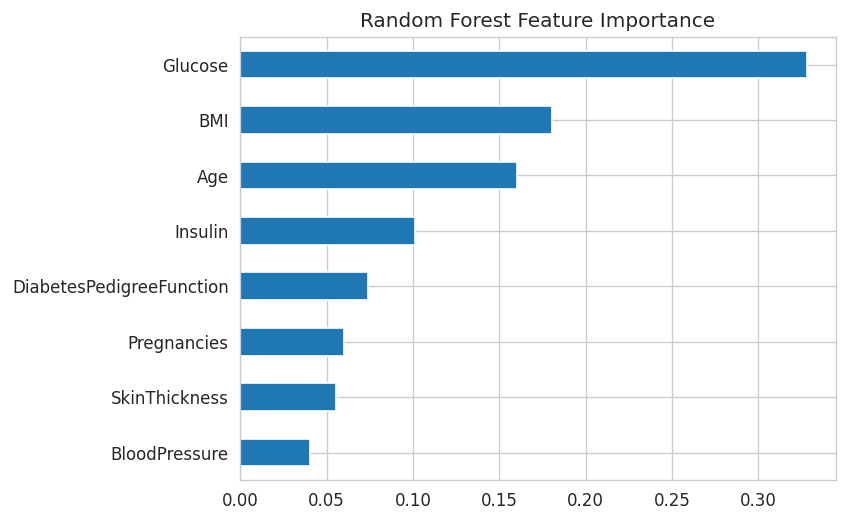

In [17]:
feat_imp = pd.Series(model.feature_importances_, index=X.columns)

feat_imp.sort_values().plot(kind="barh")
plt.title("Random Forest Feature Importance")
plt.show()

### Permutation Importance

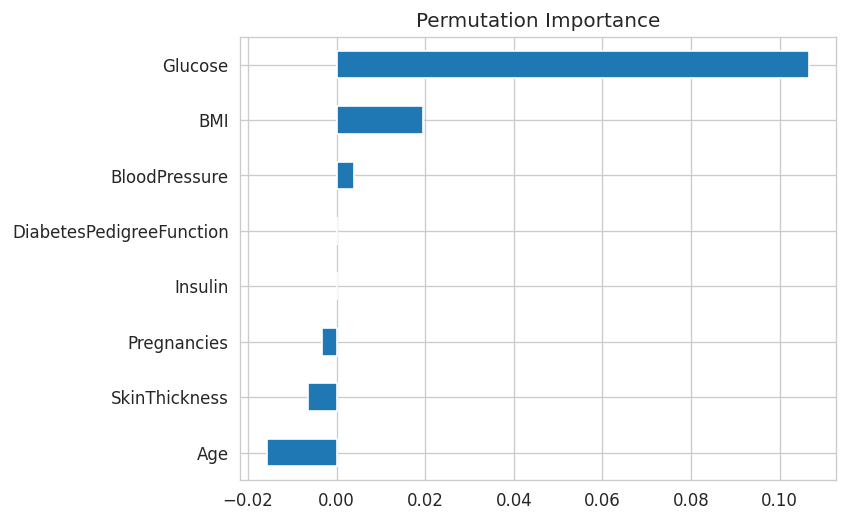

In [18]:
result = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42)

perm_imp = pd.Series(result.importances_mean, index=X.columns)

perm_imp.sort_values().plot(kind="barh")
plt.title("Permutation Importance")
plt.show()

### Feature Importance Comparison Table

In [19]:
comparison = pd.DataFrame({
    "Correlation": df_clean.corr()["Outcome"].drop("Outcome"),
    "RF Importance": model.feature_importances_,
    "Permutation Importance": result.importances_mean
})

comparison.sort_values("Permutation Importance", ascending=False)

,Correlation,RF Importance,Permutation Importance
Glucose,0.492782,0.328341,1.064935e-01
BMI,0.312038,0.180409,1.948052e-02
BloodPressure,0.165723,0.040418,3.896104e-03
Insulin,0.203790,0.101337,2.220446e-17
DiabetesPedigreeFunction,0.173844,0.073871,2.220446e-17
Pregnancies,0.221898,0.059946,-3.246753e-03
SkinThickness,0.214873,0.055305,-6.493506e-03
Age,0.238356,0.160373,-1.558442e-02


## Key Insights

- Glucose is the most important feature across all methods.
- BMI is consistently a strong predictor.
- Blood Pressure shows variation between statistical and model-based methods.
- Age contributes through interactions rather than direct influence.

## Conclusion

This analysis shows that glucose and BMI are the most reliable predictors of diabetes.

It also demonstrates that model-based methods capture relationships that simple correlation cannot.